In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno   # Missing Value Visualization

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
df = pd.read_csv(r"D:\Open Projects 2026\Finance\Dataset\finclub-open-project-26\dataset.csv")

In [4]:
print("No. of Rows:", df.shape[0])
print("No. of Columns:", df.shape[1])

No. of Rows: 975
No. of Columns: 30


In [5]:
df.shape

(975, 30)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             975 non-null    str    
 1   underlying_price     975 non-null    float64
 2   NIFTY27JAN2625200CE  781 non-null    float64
 3   NIFTY27JAN2625300CE  791 non-null    float64
 4   NIFTY27JAN2625400CE  773 non-null    float64
 5   NIFTY27JAN2625500CE  794 non-null    float64
 6   NIFTY27JAN2625600CE  795 non-null    float64
 7   NIFTY27JAN2625700CE  774 non-null    float64
 8   NIFTY27JAN2625800CE  765 non-null    float64
 9   NIFTY27JAN2625900CE  793 non-null    float64
 10  NIFTY27JAN2626000CE  794 non-null    float64
 11  NIFTY27JAN2626100CE  792 non-null    float64
 12  NIFTY27JAN2626200CE  766 non-null    float64
 13  NIFTY27JAN2626300CE  788 non-null    float64
 14  NIFTY27JAN2626400CE  762 non-null    float64
 15  NIFTY27JAN2626500CE  791 non-null    float64
 16  N

A Call Option is bought when you think the market will go up.

A Put Option is bought when you think the market will go down.

In [7]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
datetime                 0
underlying_price         0
NIFTY27JAN2625200CE    194
NIFTY27JAN2625300CE    184
NIFTY27JAN2625400CE    202
NIFTY27JAN2625500CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2625700CE    201
NIFTY27JAN2625800CE    210
NIFTY27JAN2625900CE    182
NIFTY27JAN2626000CE    181
NIFTY27JAN2626100CE    183
NIFTY27JAN2626200CE    209
NIFTY27JAN2626300CE    187
NIFTY27JAN2626400CE    213
NIFTY27JAN2626500CE    184
NIFTY27JAN2623800PE    203
NIFTY27JAN2623900PE    201
NIFTY27JAN2624000PE    209
NIFTY27JAN2624100PE    176
NIFTY27JAN2624200PE    217
NIFTY27JAN2624300PE    189
NIFTY27JAN2624400PE    202
NIFTY27JAN2624500PE    195
NIFTY27JAN2624600PE    198
NIFTY27JAN2624700PE    175
NIFTY27JAN2624800PE    209
NIFTY27JAN2624900PE    195
NIFTY27JAN2625000PE    195
NIFTY27JAN2625100PE    205
dtype: int64


In [8]:
print(df.isna().sum().sum())

5460


In [9]:
print(df.columns.tolist())

['datetime', 'underlying_price', 'NIFTY27JAN2625200CE', 'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625500CE', 'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625800CE', 'NIFTY27JAN2625900CE', 'NIFTY27JAN2626000CE', 'NIFTY27JAN2626100CE', 'NIFTY27JAN2626200CE', 'NIFTY27JAN2626300CE', 'NIFTY27JAN2626400CE', 'NIFTY27JAN2626500CE', 'NIFTY27JAN2623800PE', 'NIFTY27JAN2623900PE', 'NIFTY27JAN2624000PE', 'NIFTY27JAN2624100PE', 'NIFTY27JAN2624200PE', 'NIFTY27JAN2624300PE', 'NIFTY27JAN2624400PE', 'NIFTY27JAN2624500PE', 'NIFTY27JAN2624600PE', 'NIFTY27JAN2624700PE', 'NIFTY27JAN2624800PE', 'NIFTY27JAN2624900PE', 'NIFTY27JAN2625000PE', 'NIFTY27JAN2625100PE']


We have 14 CE options from strikes 25200 to 26500

We have 14 PE options from strikes 23800 to 25100

In [10]:
df.head(3)

,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN


In [11]:
print(df['underlying_price'].describe())

count      975.000000
mean     25564.155846
std        317.642518
min      24940.700000
25%      25266.850000
50%      25624.200000
75%      25768.200000
max      26183.800000
Name: underlying_price, dtype: float64


In [12]:
total_missing = df.isna().sum().sum()
print("Total Missing Values:", total_missing)

missing_percent = total_missing / (df.shape[0] * df.shape[1]) * 100
print("Missing %:", missing_percent)

Total Missing Values: 5460
Missing %: 18.666666666666668


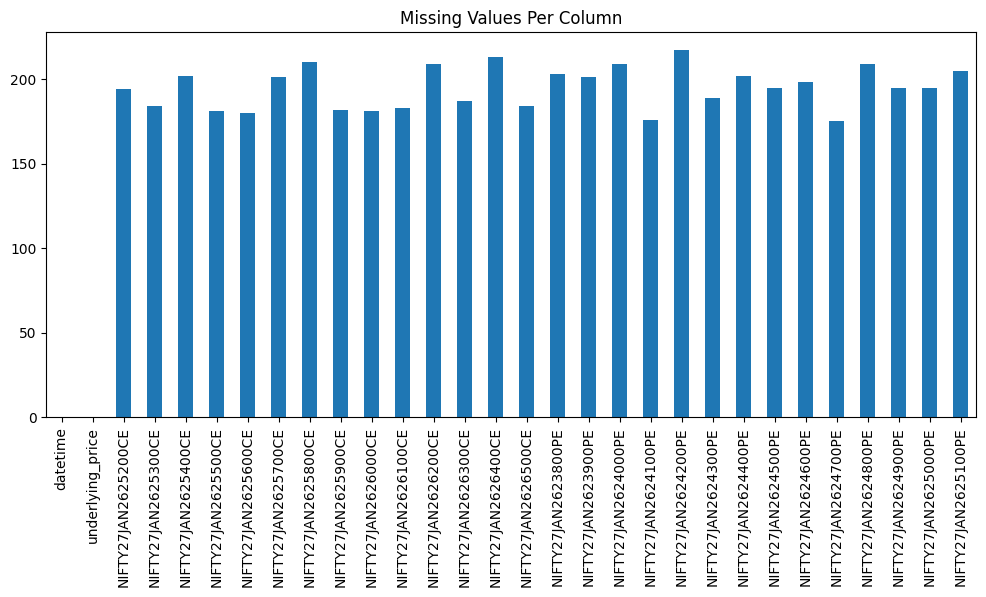

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
df.isna().sum().plot(kind='bar')
plt.title("Missing Values Per Column")
plt.show()

In [14]:
option_cols = df.columns[2:]

long_df = df.melt(           # melt goes column by column
    id_vars=["datetime", "underlying_price"],
    value_vars=option_cols,
    var_name="option",
    value_name="iv"
)

long_df["strike"] = long_df["option"].str.extract(r'(\d{5})(CE|PE)')[0].astype(int)

long_df["option_type"] = long_df["option"].str.extract(r'(CE|PE)$')[0]

long_df["moneyness"] = (
    long_df["strike"] / long_df["underlying_price"]
)

print(long_df.shape)
long_df.head()

(27300, 7)


,datetime,underlying_price,option,iv,strike,option_type,moneyness
0,07-01-2026 09:15,26111.65,NIFTY27JAN2625200CE,0.12662,25200,CE,0.965086
1,07-01-2026 09:20,26141.40,NIFTY27JAN2625200CE,0.08632,25200,CE,0.963988
2,07-01-2026 09:25,26139.35,NIFTY27JAN2625200CE,0.09147,25200,CE,0.964064
3,07-01-2026 09:30,26128.95,NIFTY27JAN2625200CE,0.10860,25200,CE,0.964447
4,07-01-2026 09:35,26131.90,NIFTY27JAN2625200CE,0.10462,25200,CE,0.964339


A partilar strike is given for all timestamps, then similarly other strike is given for all timestamps

In [15]:
long_df["datetime"] = pd.to_datetime(
    long_df["datetime"],
    dayfirst=True
)

long_df["minute_of_day"] = (
    long_df["datetime"].dt.hour * 60
    + long_df["datetime"].dt.minute
)

In [16]:
long_df.head()

,datetime,underlying_price,option,iv,strike,option_type,moneyness,minute_of_day
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,25200,CE,0.965086,555
1,2026-01-07 09:20:00,26141.40,NIFTY27JAN2625200CE,0.08632,25200,CE,0.963988,560
2,2026-01-07 09:25:00,26139.35,NIFTY27JAN2625200CE,0.09147,25200,CE,0.964064,565
3,2026-01-07 09:30:00,26128.95,NIFTY27JAN2625200CE,0.10860,25200,CE,0.964447,570
4,2026-01-07 09:35:00,26131.90,NIFTY27JAN2625200CE,0.10462,25200,CE,0.964339,575


In [17]:
train_df = long_df[long_df["iv"].notna()].copy()
test_df = long_df[long_df["iv"].isna()].copy()

print(train_df.shape)
print(test_df.shape)

(21840, 8)
(5460, 8)


In [18]:
train_df["iv"].describe()

count    21840.000000
mean         0.182937
std          0.219077
min          0.016800
25%          0.110040
50%          0.130620
75%          0.168563
max          5.384760
Name: iv, dtype: float64

In [19]:
train_df[train_df["iv"] > 1].sort_values("iv", ascending=False).head(20)

,datetime,underlying_price,option,iv,strike,option_type,moneyness,minute_of_day
15599,2026-01-27 15:25:00,25242.40,NIFTY27JAN2623900PE,5.38476,23900,PE,0.946820,925
16574,2026-01-27 15:25:00,25242.40,NIFTY27JAN2624000PE,4.97453,24000,PE,0.950781,925
17549,2026-01-27 15:25:00,25242.40,NIFTY27JAN2624100PE,4.59339,24100,PE,0.954743,925
18524,2026-01-27 15:25:00,25242.40,NIFTY27JAN2624200PE,4.21172,24200,PE,0.958704,925
19499,2026-01-27 15:25:00,25242.40,NIFTY27JAN2624300PE,3.82927,24300,PE,0.962666,925
10724,2026-01-27 15:25:00,25242.40,NIFTY27JAN2626200CE,3.74259,26200,CE,1.037936,925
13648,2026-01-27 15:20:00,25198.10,NIFTY27JAN2626500CE,3.69076,26500,CE,1.051667,920
20474,2026-01-27 15:25:00,25242.40,NIFTY27JAN2624400PE,3.44575,24400,PE,0.966628,925
16573,2026-01-27 15:20:00,25198.10,NIFTY27JAN2624000PE,3.40433,24000,PE,0.952453,920
14622,2026-01-27 15:15:00,25174.85,NIFTY27JAN2623800PE,3.17201,23800,PE,0.945388,915


In [20]:
print("IV > 1 :", (train_df["iv"] > 1).sum())
print("IV > 2 :", (train_df["iv"] > 2).sum())
print("IV > 3 :", (train_df["iv"] > 3).sum())

IV > 1 : 307
IV > 2 : 50
IV > 3 : 13


Huge IV values occur on the expiry day, near market close

In [21]:
train_df.groupby("option_type")["moneyness"].describe()

,count,mean,std,min,25%,50%,75%,max
option_type,,,,,,,,
CE,10959.0,1.011340,0.020199,0.962427,0.996520,1.011177,1.025840,1.062363
PE,10881.0,0.956612,0.019829,0.908959,0.941978,0.956475,0.971059,1.006238


In [22]:
train_df.groupby("option_type")["iv"].mean()

option_type
CE    0.166931
PE    0.199059
Name: iv, dtype: float64

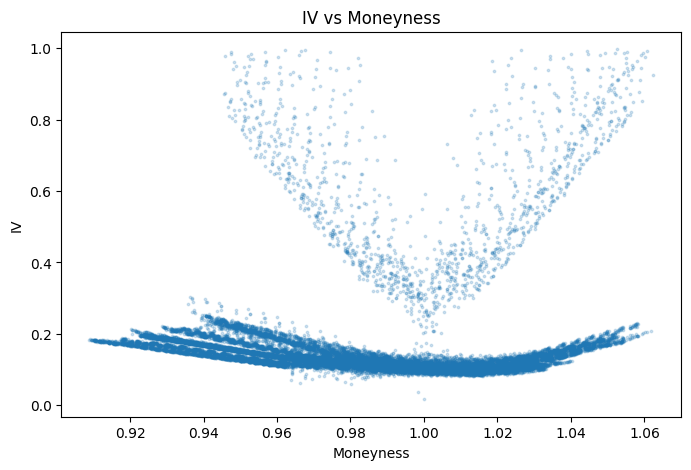

In [23]:
import matplotlib.pyplot as plt

sample = train_df[train_df["iv"] < 1].copy()

plt.figure(figsize=(8,5))
plt.scatter(
    sample["moneyness"],
    sample["iv"],
    s=3,
    alpha=0.2
)
plt.xlabel("Moneyness")
plt.ylabel("IV")
plt.title("IV vs Moneyness")
plt.show()

In [24]:
train_df.groupby("option_type")["iv"].describe()

,count,mean,std,min,25%,50%,75%,max
option_type,,,,,,,,
CE,10959.0,0.166931,0.217520,0.01680,0.10165,0.11156,0.131065,3.74259
PE,10881.0,0.199059,0.219466,0.08191,0.13042,0.15566,0.183350,5.38476


In [25]:
from sklearn.model_selection import train_test_split

features = [
    "underlying_price",
    "strike",
    "moneyness"
]

# Encode CE=1, PE=0
train_df["option_type_num"] = (
    train_df["option_type"] == "CE"
).astype(int)

features.append("option_type_num")

X = train_df[features]
y = train_df["iv"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(17472, 4)
(4368, 4)


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_val)

mse = mean_squared_error(y_val, preds)

print("Validation MSE:", mse)

Validation MSE: 0.010758752393577103


In [27]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
0,underlying_price,0.749899
2,moneyness,0.200116
1,strike,0.048766
3,option_type_num,0.001219


In [28]:
train_df["day"] = train_df["datetime"].dt.day
test_df["day"] = test_df["datetime"].dt.day

In [29]:
train_df[["datetime", "day"]].head()

,datetime,day
0,2026-01-07 09:15:00,7
1,2026-01-07 09:20:00,7
2,2026-01-07 09:25:00,7
3,2026-01-07 09:30:00,7
4,2026-01-07 09:35:00,7


In [30]:
features = [
    "underlying_price",
    "strike",
    "moneyness",
    "option_type_num",
    "day"
]

In [31]:
X = train_df[features]
y = train_df["iv"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_val)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_val, preds)

print("Validation MSE:", mse)

Validation MSE: 0.004378990385374857


In [33]:
X = train_df[features]
y = train_df["iv"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_val)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_val, preds)

print("Validation MSE:", mse)

Validation MSE: 0.004378990385374856


In [35]:
long_df[long_df["datetime"] == long_df["datetime"].iloc[0]][
    ["option", "strike", "option_type", "iv"]
].sort_values(["option_type", "strike"])

,option,strike,option_type,iv
0,NIFTY27JAN2625200CE,25200,CE,0.12662
975,NIFTY27JAN2625300CE,25300,CE,0.12330
1950,NIFTY27JAN2625400CE,25400,CE,0.11741
2925,NIFTY27JAN2625500CE,25500,CE,NaN
3900,NIFTY27JAN2625600CE,25600,CE,0.11005
4875,NIFTY27JAN2625700CE,25700,CE,0.10576
5850,NIFTY27JAN2625800CE,25800,CE,NaN
6825,NIFTY27JAN2625900CE,25900,CE,0.09724
7800,NIFTY27JAN2626000CE,26000,CE,0.09570
8775,NIFTY27JAN2626100CE,26100,CE,0.09397


In [36]:
long_df.groupby("datetime")["iv"].count().describe()

count    975.000000
mean      22.400000
std        2.069134
min       14.000000
25%       21.000000
50%       23.000000
75%       24.000000
max       28.000000
Name: iv, dtype: float64

In [37]:
features = [
    "underlying_price",
    "strike",
    "moneyness",
    "option_type_num",
    "day"
]

X_full = train_df[features]
y_full = train_df["iv"]

rf_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_full, y_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
test_df["option_type_num"] = (
    test_df["option_type"] == "CE"
).astype(int)

In [39]:
print(test_df.columns)

Index(['datetime', 'underlying_price', 'option', 'iv', 'strike', 'option_type',
       'moneyness', 'minute_of_day', 'day', 'option_type_num'],
      dtype='str')


In [40]:
X_missing = test_df[features]

test_df["pred_iv"] = rf_final.predict(X_missing)

In [41]:
long_df_pred = long_df.copy()

long_df_pred.loc[
    long_df_pred["iv"].isna(),
    "iv"
] = test_df["pred_iv"].values

In [42]:
print(long_df_pred["iv"].isna().sum())

0


In [43]:
final_df = long_df_pred.pivot(
    index=["datetime", "underlying_price"],
    columns="option",
    values="iv"
).reset_index()

In [44]:
final_df.shape

(975, 30)

In [45]:
print(df.shape)
print(final_df.shape)

(975, 30)
(975, 30)


In [46]:
final_df.head()

option,datetime,underlying_price,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE
0,2026-01-07 09:15:00,26111.65,0.17840,0.172370,0.169280,0.163597,0.157600,0.152400,0.14697,0.14105,0.136130,0.13085,0.126400,0.12142,0.116310,0.111500,0.12662,0.123300,0.117410,0.119142,0.11005,0.10576,0.105114,0.097240,0.09570,0.093970,0.09187,0.09041,0.08908,0.087950
1,2026-01-07 09:20:00,26141.40,0.17962,0.174770,0.171504,0.165340,0.159638,0.154200,0.14753,0.14274,0.138490,0.13282,0.127091,0.12363,0.116679,0.113530,0.08632,0.111257,0.115219,0.117790,0.11197,0.11028,0.100102,0.097407,0.09837,0.096190,0.09413,0.09236,0.09057,0.089250
2,2026-01-07 09:25:00,26139.35,0.18010,0.175740,0.171540,0.165670,0.159270,0.152684,0.14919,0.14245,0.138060,0.13242,0.128770,0.12349,0.118170,0.110386,0.09147,0.115757,0.095140,0.099330,0.09599,0.09204,0.092160,0.089540,0.08996,0.088610,0.08697,0.08627,0.08541,0.084953
3,2026-01-07 09:30:00,26128.95,0.18174,0.176333,0.172060,0.165020,0.157550,0.153039,0.14691,0.14209,0.137210,0.13184,0.127220,0.12252,0.117290,0.112000,0.10860,0.108420,0.111500,0.122480,0.10715,0.11098,0.103450,0.097877,0.09864,0.095110,0.09304,0.09123,0.08846,0.088430
4,2026-01-07 09:35:00,26131.90,0.18193,0.176129,0.172260,0.165220,0.159240,0.153340,0.14784,0.14230,0.136826,0.13219,0.127330,0.12295,0.117070,0.110783,0.10462,0.105380,0.124590,0.120510,0.11225,0.11294,0.105440,0.097635,0.09896,0.093162,0.09412,0.09136,0.09014,0.088850


In [47]:
print(final_df.shape)
print(final_df.isna().sum().sum())

(975, 30)
0


In [48]:
final_df.to_csv(
    "filled_dataset.csv",
    index=False
)

### Running the converter notebook

In [49]:
import pandas as pd

ORIGINAL_DATASET_PATH = r"D:\Open Projects 2026\Finance\Dataset\finclub-open-project-26\dataset.csv"
SEPARATOR = "||"

def generate_solution(filled_path: str, output_path: str = "solution.csv"):
    original = pd.read_csv(ORIGINAL_DATASET_PATH)
    filled = pd.read_csv(filled_path)

    feature_cols = [c for c in original.columns if c != "datetime"]

    rows = []
    for col in feature_cols:
        was_missing = original[col].isna()

        for idx in original.index[was_missing]:
            dt = original.loc[idx, "datetime"]
            uid = f"{dt}{SEPARATOR}{col}"
            val = filled.loc[idx, col]
            rows.append({"id": uid, "value": val})

    solution = pd.DataFrame(rows, columns=["id", "value"])
    solution = solution.sort_values("id").reset_index(drop=True)
    solution.to_csv(output_path, index=False)

    print(f" Solution saved → {output_path} ({len(solution)} rows)")

In [51]:
generate_solution(
    "filled_dataset.csv",
    r"D:\Open Projects 2026\Finance\Dataset\finclub-open-project-26\submissionn.csv"
)

 Solution saved → D:\Open Projects 2026\Finance\Dataset\finclub-open-project-26\submissionn.csv (5460 rows)
